## Importar las librerias a usar.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score

### Carga de Datasets

In [4]:
# se utiliza squeeze para convertir de serie a DataFrame ya que scikitlearn solo funciona con DataFrame y este archivo y_train solo usa una variable

X_train = pd.read_csv('../clasificacion/X_train.csv')
X_test = pd.read_csv( '../clasificacion/X_test.csv')
y_train = pd.read_csv('../clasificacion/y_train.csv').squeeze()
y_test = pd.read_csv('../clasificacion/y_test.csv').squeeze()

In [6]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

#prediccion - probabilidad
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print("Modelo Listo. Predicciones generadas:", len(y_test), "Pasajeros de prueba")


Modelo Listo. Predicciones generadas: 179 Pasajeros de prueba


In [8]:
#Accuracy - prediccion que siempre salga "no sobrevivieron"
prediccion_tonta = [0] * len(y_test)

accuracy_tonta = accuracy_score(y_test, prediccion_tonta)
accuracy_modelo = accuracy_score(y_test, y_pred)

print(f"Accuracy de un modelo que siempre predice 'No Sobrevivio': {accuracy_tonta:.4f}")
print(f"Accuracy de nuestro modelo real: {accuracy_modelo:.4f}")


Accuracy de un modelo que siempre predice 'No Sobrevivio': 0.5866
Accuracy de nuestro modelo real: 0.8156


In [11]:
#Matriz de confusion

matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusion")
print(matriz)
print()
print(f"Verdadero Negativo (VN): {matriz[0][0]}, predijo 'no sobrevivio' y acerto")
print(f"Falso Positivo (FP): {matriz[0][1]} predijo 'sobrevivio' pero no sobrevivio")
print(f"Falso Negativo (FN): {matriz[1][0]} predijo 'No sotrevivio' pero si sobrevivio")
print(f"Verdadero Positivo (VP): {matriz[1][1]} predijo 'sobrevivio' y acerto")



Matriz de confusion
[[90 15]
 [18 56]]

Verdadero Negativo (VN): 90, predijo 'no sobrevivio' y acerto
Falso Positivo (FP): 15 predijo 'sobrevivio' pero no sobrevivio
Falso Negativo (FN): 18 predijo 'No sotrevivio' pero si sobrevivio
Verdadero Positivo (VP): 56 predijo 'sobrevivio' y acerto


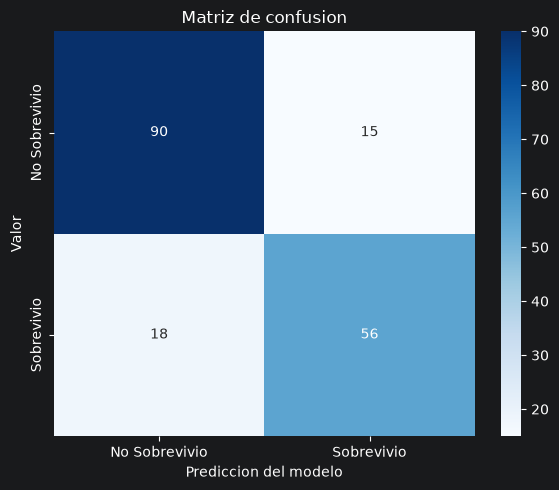

In [13]:
#visualizar Matriz de Confusion

plt.figure(figsize=(6, 5))
#annot=True le dice a seaborn que escriba el numero dentro de cada celda
#fmt='d' decide el formato
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Sobrevivio', 'Sobrevivio'],
            yticklabels=['No Sobrevivio', 'Sobrevivio'])
plt.title('Matriz de confusion')
plt.xlabel('Prediccion del modelo')
plt.ylabel('Valor')
plt.tight_layout()
plt.savefig('../graficas/02_matriz_confusion.png')
plt.show()


### Interpretacion de los Resultados de la matriz de confusion:

El modelo muestra un buen rendimiento general. La mayoría de las predicciones correctas se concentran en la diagonal principal de la matriz de confusión, lo que indica que el algoritmo está aprendiendo los patrones del conjunto de datos. No obstante, existen 33 clasificaciones incorrectas, principalmente relacionadas con la identificación de los supervivientes, lo que sugiere que todavía existe margen para mejorar el modelo.

In [15]:
#Metricas Precision, Recall, F1
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

#precision = vp / (vp + fp)
#recall = vp / (vp + fn)
#F1 = 2 X (Precision * recall) / (Precision + recall)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

Precision: 0.7887
Recall: 0.7568
F1: 0.7724


In [23]:
#Metrica classificacion_report
print("Classificacion Report:")
print()
print(classification_report(y_test, y_pred, target_names=['No Sobrevivio', 'Sobrevivio']))

Classificacion Report:

               precision    recall  f1-score   support

No Sobrevivio       0.83      0.86      0.85       105
   Sobrevivio       0.79      0.76      0.77        74

     accuracy                           0.82       179
    macro avg       0.81      0.81      0.81       179
 weighted avg       0.81      0.82      0.82       179



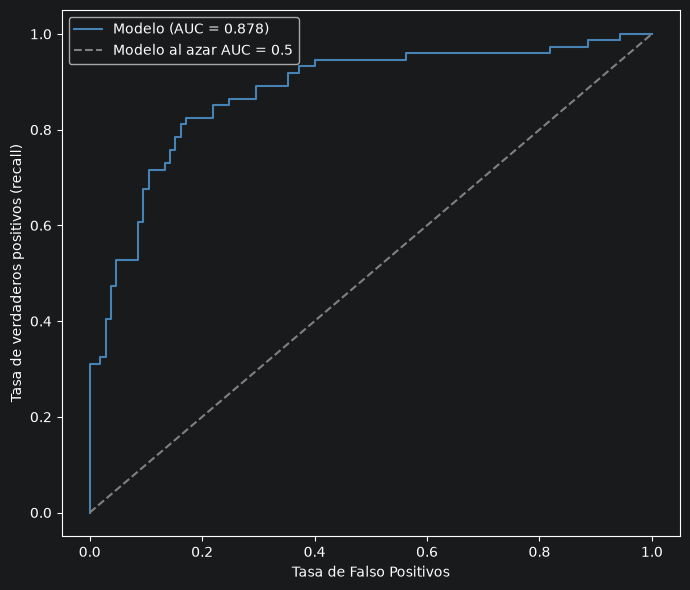

AUC (Area bajo la Curva: 0.8776


In [29]:
# Curva ROC y AUC
#FPT (False Positive Rate) mientras mas bajo mejor, TPR (True Positive Rate)

fpr, tpr, umbrales = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', label=f"Modelo (AUC = {auc:.3f})")
#0.5 el modelo no es mejor que adivine al azar, 1.0 significa que el modelo esta separando a las clases a la perfeccion.
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Modelo al azar AUC = 0.5')
plt.xlabel('Tasa de Falso Positivos')
plt.ylabel('Tasa de verdaderos positivos (recall)')
plt.legend()
plt.tight_layout()
plt.savefig('../graficas/03_roc_curve.png')
plt.show()


print(f'AUC (Area bajo la Curva: {auc:.4f}')

## Interpretación de la curva ROC

El modelo obtuvo un AUC de 0.8776.

Esto significa que tiene una capacidad del 87.76 % para diferenciar entre los pasajeros que sobrevivieron y los que no sobrevivieron.

La curva ROC se mantiene muy por encima de la línea diagonal, que representa un modelo aleatorio con un AUC de 0.5.

Estos resultados indican que el modelo tiene un buen rendimiento y que es capaz de clasificar correctamente la mayoría de los pasajeros del conjunto de datos.